In [2]:
import sys
sys.path.append('../')
from utils_models import *
from scipy.optimize import minimize


In [3]:
with open('../pickles/mesolve_wd1649_final_computational_1em3.pkl', 'rb') as file:
    results_compu_1em3 = pickle.load(file)

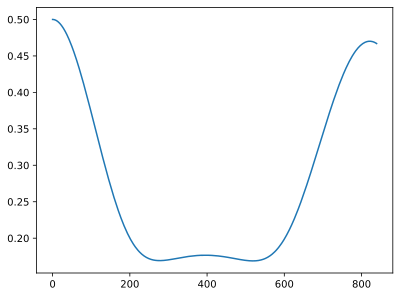

In [6]:
plt.plot([ abs(state[1,0]) for state in results_compu_1em3[2].states_dressed_to_2_level_dm])

In [4]:
max_ql = 20
max_ol = 50
system = FluxoniumOscillatorSystem(
    EJ = 2.33,
    EC = 0.69,
    EL = 0.12,
    Er = 7.16518677,
    g_strength = 0.18,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(20) ]+ \
                    [[ql, ol] for ql in [9,10,11] for ol in range(12) ] ,    
    computaional_states = '1,2',
    )

In [5]:
subsystem_dims = [max(indexes) + 1 for indexes in zip(*system.product_to_dressed.keys())]
# Precompute indices as before
prod_dims_cumprod = np.cumprod(subsystem_dims[::-1])[::-1]
prod_dims_cumprod_shifted = np.roll(prod_dims_cumprod, shift=-1)
prod_dims_cumprod_shifted[-1] = 1

# Assuming product_to_dressed keys are tuples like (ql, ol), compute the index for each product state
indices_map = {pstate: sum(np.array(pstate) * prod_dims_cumprod_shifted) for pstate in system.product_to_dressed.keys()}


def convert_to_product(dm):
    dressed_dm_data = dm.full()
    rho_product = np.zeros((np.prod(subsystem_dims), np.prod(subsystem_dims)), dtype=complex)

    # Now, instead of iterating and unpacking, directly use the dressed indices
    for product_state, dressed_index1 in system.product_to_dressed.items():
        index1 = indices_map[product_state]  # Use precomputed index
        for product_state2, dressed_index2 in system.product_to_dressed.items():
            index2 = indices_map[product_state2]  # Use precomputed index
            # Extract element directly without unpacking
            element = dressed_dm_data[dressed_index1, dressed_index2]
            rho_product[index1, index2] += element

    rho_product = qutip.Qobj(rho_product, dims=[subsystem_dims, subsystem_dims])
    return rho_product


def truncate_first_subsystem(rho):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full()
    rho_reshaped = rho_array.reshape((dim_1, dim_2, dim_1, dim_2))
    truncated_rho_reshaped = rho_reshaped[1:3, :, 1:3, :]
    truncated_rho_array = truncated_rho_reshaped.reshape((2 * dim_2, 2 * dim_2))
    truncated_rho = qutip.Qobj(truncated_rho_array, dims=[[2, dim_2], [2, dim_2]])
    return truncated_rho


In [97]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
state_ideal =  (zero +  one).unit()
rho =truncate_first_subsystem(convert_to_product(results_compu_1em3[3].states_pad_back_custom[400]))
theta = -1.229

dim_1 = rho.dims[0][0]
dim_2  =  rho.dims[0][1]


rho_array = rho.full().reshape((dim_1, dim_2, dim_1, dim_2))

gate = qutip.Qobj(np.array([[1, 0],
                [0, np.exp(1.0j * theta)]]))
A = qutip.ket2dm(gate*state_ideal)
sqrtmA = A.sqrtm()
weights = np.abs(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
fid_sum= 0.0 

zero_one_abs = 0
for ol in range(dim_2):

    B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]]) / weights[ol]
    eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
    fid = float(np.real(np.sqrt(eig_vals[eig_vals > 0]).sum()))
    fid_weighted = fid * weights[ol]
    print(f"{ol},\t{fid_weighted:.3e}\tweight {weights[ol]:.3e}" )
    fid_sum += fid_weighted
fid_sum
    

0,	5.486e-02	weight 3.895e-01
1,	3.659e-01	weight 3.669e-01
2,	1.409e-01	weight 1.731e-01
3,	7.161e-03	weight 5.457e-02
4,	1.040e-02	weight 1.292e-02
5,	1.216e-03	weight 2.453e-03
6,	2.894e-04	weight 3.888e-04
7,	5.287e-05	weight 5.290e-05
8,	1.319e-06	weight 6.357e-06
9,	1.063e-07	weight 6.330e-07
10,	7.896e-08	weight 9.426e-08
11,	3.590e-16	weight 1.558e-08
12,	9.929e-09	weight 1.329e-08
13,	6.548e-17	weight 6.264e-09
14,	2.094e-09	weight 2.130e-09
15,	1.755e-10	weight 3.269e-10
16,	8.767e-19	weight 5.704e-11
17,	1.088e-11	weight 2.440e-11
18,	2.409e-12	weight 5.765e-12
19,	3.652e-20	weight 3.298e-12
20,	0.000e+00	weight 0.000e+00
21,	0.000e+00	weight 0.000e+00
22,	0.000e+00	weight 0.000e+00
23,	0.000e+00	weight 0.000e+00
24,	0.000e+00	weight 0.000e+00
25,	0.000e+00	weight 0.000e+00
26,	0.000e+00	weight 0.000e+00
27,	0.000e+00	weight 0.000e+00
28,	0.000e+00	weight 0.000e+00
29,	0.000e+00	weight 0.000e+00
30,	0.000e+00	weight 0.000e+00
31,	0.000e+00	weight 0.000e+00
32,	0.000e+00	weig

0.5807136766664461

In [51]:
results_compu_1em3[2].states_dressed_to_2_level_dm[400][0,1]

(0.05666402293459421+0.1673039838835545j)

In [87]:

rho = truncate_first_subsystem(convert_to_product(results_compu_1em3[3].states_pad_back_custom[11]))
rho_array = rho.full().reshape((dim_1, dim_2, dim_1, dim_2))
weights = np.abs(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
ol = 0
normalized_o0 = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]]) / weights[ol]
ol = 1
normalized_o1 = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]]) / weights[ol]
normalized_o0, normalized_o1, weights[0], weights[1]

(Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
 Qobj data =
 [[ 0.49999979+0.j         -0.06728808-0.49545162j]
  [-0.06728808+0.49545162j  0.50000021+0.j        ]],
 Quantum object: dims = [[2], [2]], shape = (2, 2), type = oper, isherm = True
 Qobj data =
 [[ 0.50021324+0.j         -0.15039605+0.47684481j]
  [-0.15039605-0.47684481j  0.49978676+0.j        ]],
 0.9979966412041732,
 0.002001340560203043)

In [57]:
zero = qutip.basis(2, 0)
one = qutip.basis(2, 1)
states_ideal  = [zero,
                one,
                (zero +  one).unit(),
                (zero - 1j * one).unit(),
                ]


def calc_infidelity_with_phase(phase,dm,state_ideal):
    gate = qutip.qip.operations.phasegate(phase)
    state_ideal = gate*state_ideal
    return 1-qutip.fidelity(dm, state_ideal)
def calc_weighted_infidelity_with_phase(theta,rho,state_ideal):
    dim_1 = rho.dims[0][0]
    dim_2  =  rho.dims[0][1]
    rho_array = rho.full().reshape((dim_1, dim_2, dim_1, dim_2))

    gate = qutip.Qobj(np.array([[1, 0],
                    [0, np.exp(1.0j * theta)]]))
    A = qutip.ket2dm(gate*state_ideal)
    sqrtmA = A.sqrtm()
    weights = np.abs(np.diag(np.trace(rho_array, axis1=0, axis2=2)))
    fid_sum= 0.0 
    for ol in range(dim_2):
        B = qutip.Qobj(rho_array[:, ol, :, ol].reshape((dim_1, dim_1)), dims=[[dim_1], [dim_1]])/ weights[ol]
        eig_vals = (sqrtmA * B * sqrtmA).eigenenergies()
        fid = float(np.abs(np.sqrt(eig_vals[eig_vals > 0]).sum()))
        fid_sum += fid * weights[ol]
    return 1 - fid_sum

t_idx = 400
dms = [result.states_pad_back_custom[t_idx] for result in results_compu_1em3[:4]]
dms_two_lvl = [truncate_first_subsystem(convert_to_product(dm)) for dm in dms]
dms_partial_trace_two_lvl = [result.states_dressed_to_2_level_dm[t_idx] for result in results_compu_1em3[:4]]
def objective_function(phase):
    # infidelities = [calc_weighted_infidelity_with_phase(phase[0],
    #                                                     dm_two_lvl,
    #                                                     state_ideal)  for dm_two_lvl, state_ideal in zip(dms_two_lvl,states_ideal)]
    infidelities = [calc_infidelity_with_phase(phase[0], dm, state_ideal) for dm, state_ideal in zip(dms_partial_trace_two_lvl,states_ideal)]
    mean = np.mean(infidelities)
    return mean
initial_phase = [0.0]
bounds = [(0, 2 * 3.141592653589793)]
minimize(objective_function, initial_phase,method="COBYLA")

 message: Optimization terminated successfully.
 success: True
  status: 1
     fun: 0.08870975509044637
       x: [-1.244e+00]
    nfev: 23
   maxcv: 0.0